# Monte Carlo Option Pricing for a European Call

## Objective
The purpose of this project is to price a European call option using Monte Carlo simulation and compare the result with the Black–Scholes analytical solution.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# Model parameters
S0 = 100      # initial stock price
K = 100       # strike price
r = 0.05      # risk-free rate
sigma = 0.2   # volatility
T = 1.0       # maturity in years
q = 0.02      # annual dividend rate

# Simulation parameters
n_steps = 252
n_paths = 10000

## Model Assumption

We assume the stock price follows Geometric Brownian Motion:


$dS_t = r S_t dt + \sigma S_t dW_t$


Under the risk-neutral measure, the discrete-time simulation formula is:


$S_{t+\Delta t} = S_t \exp\left((r - \frac{1}{2}\sigma^2)\Delta t + \sigma \sqrt{\Delta t} Z\right)$

where $(Z \sim N(0,1)$).

For a European call option, the payoff at maturity is:

$max(S_T - K, 0)$, where K is the strike price


The Monte Carlo price is the discounted expected payoff:


$C = e^{-rT} \mathbb{E}[\max(S_T - K, 0)]$

(252, 10000)


Text(0.5, 1.0, 'Geometric Brownian Motion')

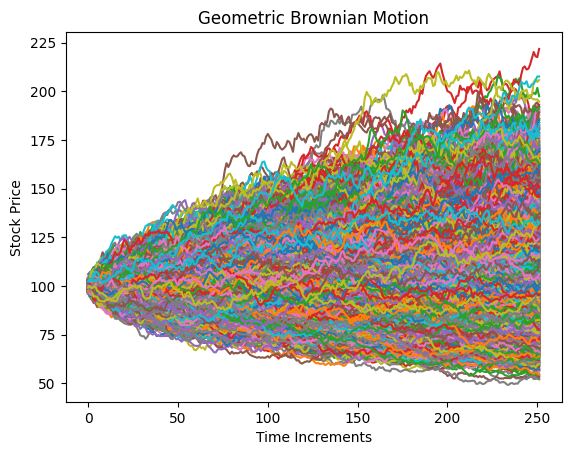

In [ ]:
def gbm_paths(S, r, q, sigma, T, n_steps, n_paths):
    """Simulate stock price paths using geometric Brownian motion."""
    # Change in time for each step
    dt = T / n_steps
    # Generate array of random stock paths over time
    D_t_delta_t = S*np.exp(np.cumsum((r - q * sigma**2 / 2) * dt + sigma * np.sqrt(dt) * np.random.normal(size=(n_steps, n_paths)),axis=0))
    return D_t_delta_t

paths = gbm_paths(S0, r, q, sigma, T, n_steps, n_paths)
plt.plot(paths)
plt.xlabel("Time Increments")
plt.ylabel("Stock Price")
plt.title("Geometric Brownian Motion")


The plot above shows the different paths the stock, S0, can take.

# Terminal pricing distribution

The terminal price is the price of the stock at maturity. The option payoff depends only on the price of the stock at maturity, $S_T$, which explains how the monte carlo estimator derives the option price. The terminal pricing distribution is shown below.


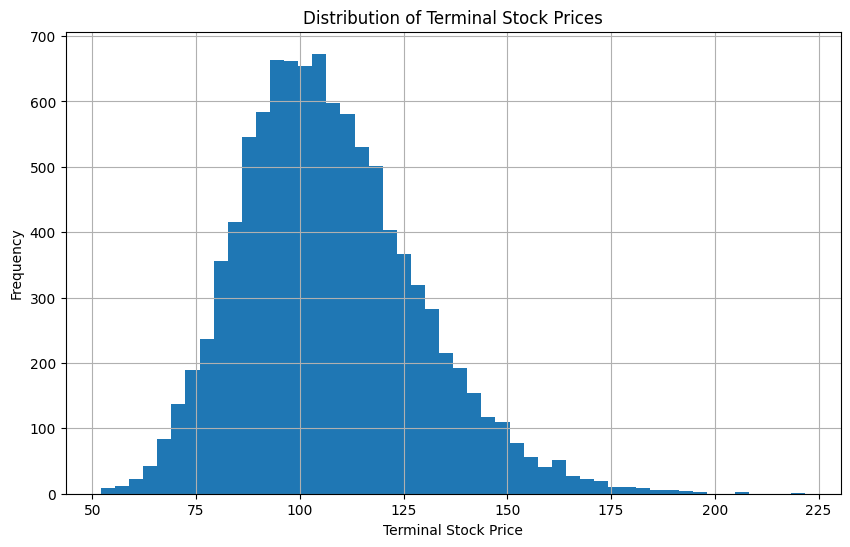

In [ ]:
# The terminal stock prices are the last row of the paths array
ST = paths[-1]

# Plot the distribution of terminal stock prices
plt.figure(figsize=(10, 6))
plt.hist(ST, bins=50)
plt.title("Distribution of Terminal Stock Prices")
plt.xlabel("Terminal Stock Price")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()